Using cached price data.

DATA
Initial capital: £10,000.00
Actual start:    2023-01-03
Actual end:      2026-08-18
Trading days:    917
Cached datasets: 7

Optimisation objectives:
Maximise: CAGR P10
Minimise: Vol P90
Minimise: DD P90

Weekly 1-year windows: 137
Allocations tested: 231
Total portfolio-window tests: 31,647
Robust Pareto portfolios: 56

YOUR 70 / 10 / 20
Equity/Bonds/Gold: 70/10/20

Optimisation metrics:
CAGR P10: 10.47%
Vol P90:  12.71%
DD P90:   9.81%

50th percentiles:
CAGR P50: 17.31%
Vol P50:  8.59%
DD P50:   8.70%
MCL P50:  1.98%
TDB P50:  11 days
MCDB P50: 7 days

Tail statistics:
DD P90/P95/P99:   9.81% / 9.85% / 9.89%
MCL P90/P95/P99:  4.37% / 7.13% / 8.83%
TDB P90/P95/P99:  67 / 81 / 117 days
MCDB P90/P95/P99: 27 / 36 / 52 days

BALANCED ROBUST PARETO CHOICE
Equity/Bonds/Gold: 50/30/20

Optimisation metrics:
CAGR P10: 10.13%
Vol P90:  10.54%
DD P90:   8.82%

50th percentiles:
CAGR P50: 15.57%
Vol P50:  6.66%
DD P50:   6.03%
MCL P50:  1.11%
TDB P50:  11 days
MCD

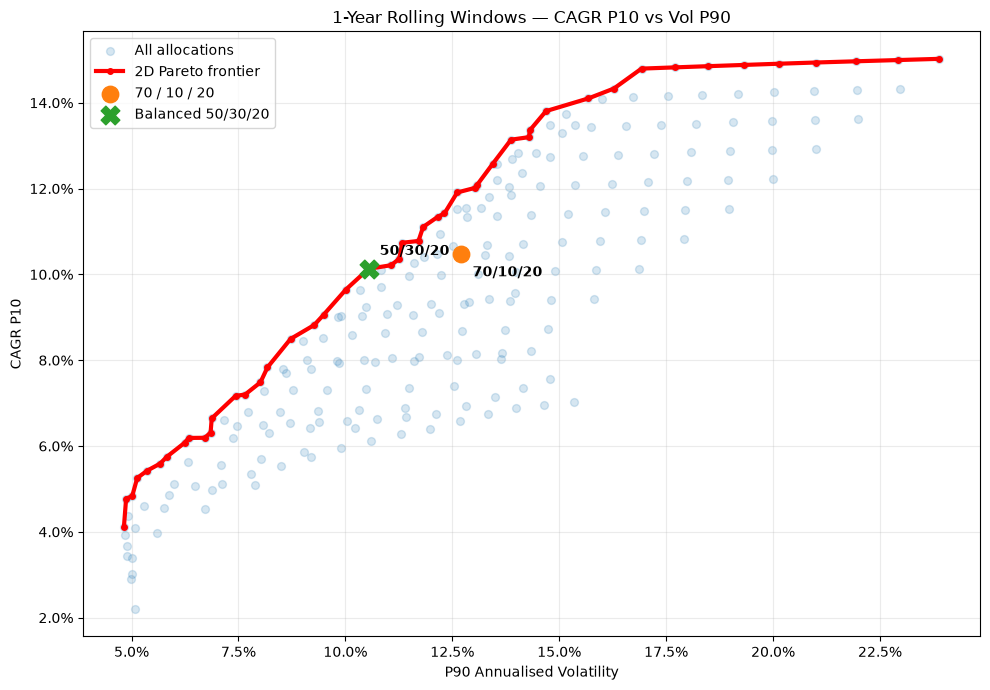

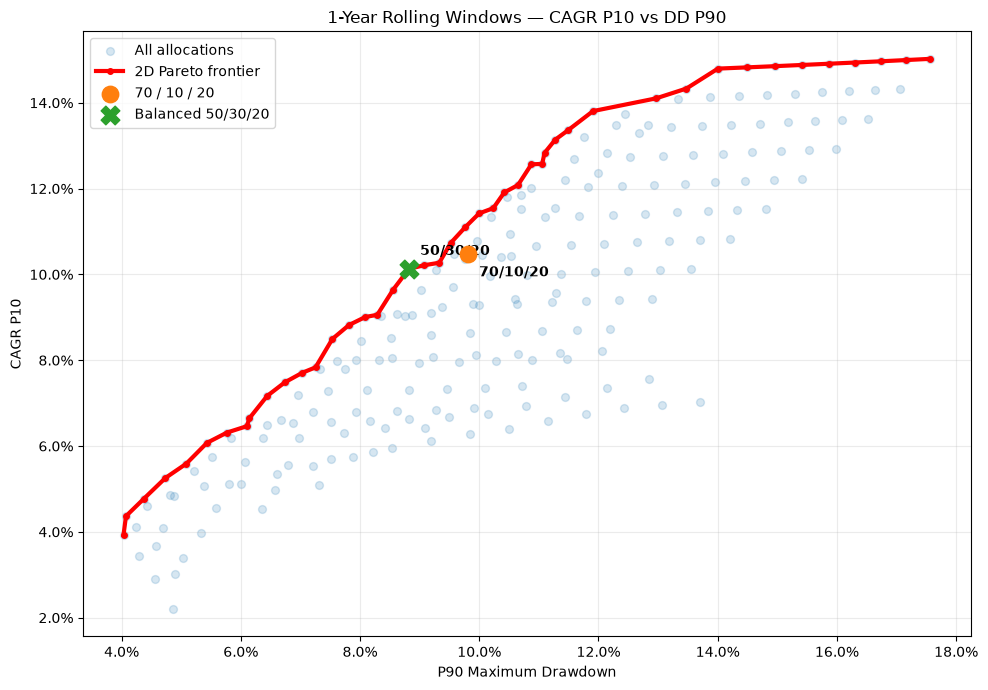

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

try:
    from IPython import get_ipython
except ImportError:
    get_ipython = lambda: None


# ============================================================
# SETTINGS
# ============================================================

START_DATE = "2023-01-01"
END_DATE = "2026-08-19"  # yfinance end date is exclusive

INITIAL_CAPITAL = 10_000
WEIGHT_STEP = 5           # 5% steps = 231 allocations
HOLDING_YEARS = 1         # Each weekly entry is held for 1 year

# Pareto optimisation percentiles.
# Higher CAGR is better; lower volatility and drawdown are better.
CAGR_PERCENTILE = 0.10    # Maximise 10th-percentile CAGR
VOL_PERCENTILE = 0.90     # Minimise 90th-percentile volatility
DD_PERCENTILE = 0.90      # Minimise 90th-percentile max drawdown

MAX_ABS_DAILY_MOVE = 0.40
MIN_TRADING_DAYS = 252


# ============================================================
# PORTFOLIO
# ============================================================

# The equity sleeve is always split equally across these ETFs.
equities = ["CSP1.L", "VUKG.L", "VERG.L", "SJPA.L", "EMIM.L"]

bond = "VAGS.L"
gold = "SGLN.L"
tickers = equities + [bond, gold]


# ============================================================
# OPTIMISATION COLUMN NAMES
# ============================================================

def percentile_label(value):
    return f"P{round(value * 100)}"


CAGR_OPT_COL = f"CAGR {percentile_label(CAGR_PERCENTILE)}"
VOL_OPT_COL = f"Vol {percentile_label(VOL_PERCENTILE)}"
DD_OPT_COL = f"DD {percentile_label(DD_PERCENTILE)}"


# ============================================================
# JUPYTER IN-MEMORY PRICE CACHE
# ============================================================

def get_price_cache():
    """
    Keep downloaded prices in memory while the same Jupyter
    kernel remains alive. Outside Jupyter, use a global dict.
    """

    ipython = get_ipython()

    if ipython is None:
        global _price_cache

        if "_price_cache" not in globals():
            _price_cache = {}

        return _price_cache

    return ipython.user_ns.setdefault("_price_cache", {})


def get_prices(tickers, start, end):
    """
    Reuse cached data when tickers/start/end are unchanged.
    """

    cache = get_price_cache()
    key = (tuple(tickers), start, end)

    if key in cache:
        print("Using cached price data.")
        return cache[key].copy()

    print("Downloading historical prices...")

    data = yf.download(tickers, start=start, end=end, auto_adjust=True, repair=True, progress=False)

    if data.empty:
        raise RuntimeError("yfinance returned no data.")

    prices = data["Close"].reindex(columns=tickers).sort_index()
    cache[key] = prices.copy()

    print("Price data stored in memory cache.")

    return prices.copy()


# ============================================================
# GET AND VALIDATE PRICE DATA
# ============================================================

prices = get_prices(tickers, START_DATE, END_DATE)

# Ensure every ETF returned some data.
missing = [ticker for ticker in tickers if prices[ticker].isna().all()]

if missing:
    raise RuntimeError("No historical data returned for: " + ", ".join(missing))

# No forward filling: use only common trading dates.
prices = prices.dropna()

if len(prices) < MIN_TRADING_DAYS:
    raise RuntimeError(f"Only {len(prices)} common trading days found.")

if (prices <= 0).any().any():
    raise RuntimeError("Zero or negative prices detected.")

# Catch obvious Yahoo price glitches.
asset_returns = prices.pct_change(fill_method=None)
suspicious = asset_returns.abs() > MAX_ABS_DAILY_MOVE

if suspicious.any().any():
    rows, cols = np.where(suspicious)
    examples = [f"{asset_returns.index[r].date()} {asset_returns.columns[c]}: {asset_returns.iloc[r, c]:.2%}" for r, c in zip(rows[:20], cols[:20])]
    raise RuntimeError("Suspicious daily price moves detected:\n" + "\n".join(examples))


print("\n" + "=" * 70)
print("DATA")
print("=" * 70)
print(f"Initial capital: £{INITIAL_CAPITAL:,.2f}")
print(f"Actual start:    {prices.index[0].date()}")
print(f"Actual end:      {prices.index[-1].date()}")
print(f"Trading days:    {len(prices):,}")
print(f"Cached datasets: {len(get_price_cache())}")

print("\nOptimisation objectives:")
print(f"Maximise: {CAGR_OPT_COL}")
print(f"Minimise: {VOL_OPT_COL}")
print(f"Minimise: {DD_OPT_COL}")


# ============================================================
# CREATE ALL ALLOCATIONS
# ============================================================

# With three sleeves summing to 100% and 5% steps there are
# 231 possible Equity / Bonds / Gold allocations.

weight_rows = []

for equity_pct in range(0, 101, WEIGHT_STEP):
    for bond_pct in range(0, 101 - equity_pct, WEIGHT_STEP):
        gold_pct = 100 - equity_pct - bond_pct
        equity_weight = equity_pct / 100 / len(equities)

        weight_rows.append({
            "Equity %": equity_pct,
            "Bonds %": bond_pct,
            "Gold %": gold_pct,
            **{ticker: equity_weight for ticker in equities},
            bond: bond_pct / 100,
            gold: gold_pct / 100,
        })

weight_df = pd.DataFrame(weight_rows)

if WEIGHT_STEP == 5 and len(weight_df) != 231:
    raise RuntimeError(f"Expected 231 portfolios, got {len(weight_df)}.")

# Weight matrix: portfolios × ETFs.
W = weight_df[tickers].to_numpy()

# ============================================================
# CREATE WEEKLY 1-YEAR WINDOWS
# ============================================================

# Only include weekly entries with a complete subsequent
# one-year holding period.

last_possible_start = prices.index[-1] - pd.DateOffset(years=HOLDING_YEARS)
weekly_anchors = pd.date_range(start=prices.index[0], end=last_possible_start, freq="W-MON")

# If Monday is unavailable, move to the next common trading day.
start_positions = np.unique(prices.index.searchsorted(weekly_anchors))
start_positions = start_positions[start_positions < len(prices)]

windows = []

for start_pos in start_positions:
    start_date = prices.index[start_pos]
    target_end = start_date + pd.DateOffset(years=HOLDING_YEARS)

    # Last common trading day on or before the target end date.
    end_pos = prices.index.searchsorted(target_end, side="right") - 1

    if end_pos <= start_pos:
        continue

    actual_years = (prices.index[end_pos] - start_date).days / 365.25

    # Require essentially the complete holding period.
    if actual_years >= HOLDING_YEARS - 0.03:
        windows.append((start_pos, end_pos, actual_years))

if not windows:
    raise RuntimeError("No valid rolling windows found.")

print()
print(f"Weekly {HOLDING_YEARS}-year windows: {len(windows):,}")
print(f"Allocations tested: {len(weight_df):,}")
print(f"Total portfolio-window tests: {len(windows) * len(weight_df):,}")


# ============================================================
# ROLLING BACKTEST
# ============================================================

cagr_windows = []
vol_windows = []
dd_windows = []

# MCL  = Maximum Capital Loss below original capital.
# TDB  = Total Trading Days Below original capital.
# MCDB = Maximum Consecutive Trading Days Below original capital.

mcl_windows = []
tdb_windows = []
mcdb_windows = []


def max_true_run(mask):
    """
    Return the longest consecutive True run for each column.
    """

    current = np.zeros(mask.shape[1], dtype=int)
    longest = np.zeros(mask.shape[1], dtype=int)

    for row in mask:
        current = np.where(row, current + 1, 0)
        longest = np.maximum(longest, current)

    return longest


for start_pos, end_pos, actual_years in windows:
    segment = prices.iloc[start_pos:end_pos + 1].to_numpy()

    # Every ETF begins at 1.0 for each new weekly entry.
    relative = segment / segment[0]

    # No rebalancing: these are initial weights only.
    values = INITIAL_CAPITAL * (relative @ W.T)

    # ========================================================
    # CAGR
    # ========================================================

    final_growth = values[-1] / INITIAL_CAPITAL
    cagrs = final_growth ** (1 / actual_years) - 1

    # ========================================================
    # ANNUALISED VOLATILITY
    # ========================================================

    daily_returns = values[1:] / values[:-1] - 1
    volatilities = daily_returns.std(axis=0, ddof=1) * np.sqrt(252)

    # ========================================================
    # MAXIMUM DRAWDOWN
    # ========================================================

    # Maximum drawdown is measured from any previous peak.
    running_max = np.maximum.accumulate(values, axis=0)
    max_drawdowns = -(values / running_max - 1).min(axis=0)

    # ========================================================
    # MAXIMUM CAPITAL LOSS — MCL
    # ========================================================

    # MCL is measured relative to ORIGINAL £10,000.
    max_capital_loss = np.maximum(0, 1 - values / INITIAL_CAPITAL).max(axis=0)

    # ========================================================
    # DAYS BELOW ORIGINAL CAPITAL
    # ========================================================

    below_capital = values < INITIAL_CAPITAL

    # Total trading days below original capital.
    total_days_below = below_capital.sum(axis=0)

    # Longest uninterrupted run below original capital.
    max_consecutive_days_below = max_true_run(below_capital)

    # ========================================================
    # STORE WINDOW RESULTS
    # ========================================================

    cagr_windows.append(cagrs)
    vol_windows.append(volatilities)
    dd_windows.append(max_drawdowns)
    mcl_windows.append(max_capital_loss)
    tdb_windows.append(total_days_below)
    mcdb_windows.append(max_consecutive_days_below)


# Matrices: weekly entry windows × portfolios.
cagr_windows = np.vstack(cagr_windows)
vol_windows = np.vstack(vol_windows)
dd_windows = np.vstack(dd_windows)
mcl_windows = np.vstack(mcl_windows)
tdb_windows = np.vstack(tdb_windows)
mcdb_windows = np.vstack(mcdb_windows)


# ============================================================
# ENTRY-TIMING DISTRIBUTIONS
# ============================================================

summary = weight_df[["Equity %", "Bonds %", "Gold %"]].copy()


def add_percentiles(df, prefix, values, percentiles):
    """
    Add percentile columns to the summary table.
    """

    for label, quantile in percentiles.items():
        df[f"{prefix} {label}"] = np.quantile(values, quantile, axis=0)


# ============================================================
# OPTIMISATION STATISTICS
# ============================================================

# These three selected percentiles drive the Pareto
# optimisation and balanced choice.

summary[CAGR_OPT_COL] = np.quantile(cagr_windows, CAGR_PERCENTILE, axis=0)
summary[VOL_OPT_COL] = np.quantile(vol_windows, VOL_PERCENTILE, axis=0)
summary[DD_OPT_COL] = np.quantile(dd_windows, DD_PERCENTILE, axis=0)


# ============================================================
# ADDITIONAL RETURN / RISK STATISTICS
# ============================================================

# P50 represents the median result across all weekly entry dates.

summary["CAGR P10"] = np.quantile(cagr_windows, 0.10, axis=0)
summary["CAGR P50"] = np.quantile(cagr_windows, 0.50, axis=0)
summary["CAGR P90"] = np.quantile(cagr_windows, 0.90, axis=0)

summary["Vol P50"] = np.quantile(vol_windows, 0.50, axis=0)
summary["Vol P90"] = np.quantile(vol_windows, 0.90, axis=0)

report_percentiles = {"P50": 0.50, "P90": 0.90, "P95": 0.95, "P99": 0.99}

add_percentiles(summary, "DD", dd_windows, report_percentiles)
add_percentiles(summary, "MCL", mcl_windows, report_percentiles)
add_percentiles(summary, "TDB", tdb_windows, report_percentiles)
add_percentiles(summary, "MCDB", mcdb_windows, report_percentiles)


# ============================================================
# ROBUST 3-OBJECTIVE PARETO SET
# ============================================================

# Capital-loss metrics do NOT affect Pareto dominance.
#
# Maximise:
#     selected CAGR percentile
#
# Minimise:
#     selected volatility percentile
#     selected drawdown percentile

returns = summary[CAGR_OPT_COL].to_numpy()
volatility = summary[VOL_OPT_COL].to_numpy()
drawdown = summary[DD_OPT_COL].to_numpy()

is_pareto = np.ones(len(summary), dtype=bool)

for i in range(len(summary)):
    dominated = (
        (returns >= returns[i])
        & (volatility <= volatility[i])
        & (drawdown <= drawdown[i])
        & ((returns > returns[i]) | (volatility < volatility[i]) | (drawdown < drawdown[i]))
    )

    if dominated.any():
        is_pareto[i] = False

robust_pareto = summary[is_pareto].copy()

print(f"Robust Pareto portfolios: {len(robust_pareto)}")


# ============================================================
# BALANCED ROBUST PARETO CHOICE
# ============================================================

# The representative choice gives equal normalised importance
# to the three selected optimisation objectives.

def scale01(series):
    span = series.max() - series.min()

    if span == 0:
        return pd.Series(0.0, index=series.index)

    return (series - series.min()) / span


pareto_choice = robust_pareto.copy()

return_good = scale01(pareto_choice[CAGR_OPT_COL])
vol_good = 1 - scale01(pareto_choice[VOL_OPT_COL])
dd_good = 1 - scale01(pareto_choice[DD_OPT_COL])

pareto_choice["Distance to Ideal"] = np.sqrt((1 - return_good) ** 2 + (1 - vol_good) ** 2 + (1 - dd_good) ** 2)

choice = pareto_choice.nsmallest(1, "Distance to Ideal").iloc[0]


# ============================================================
# FIND 70 / 10 / 20
# ============================================================

current = summary[
    (summary["Equity %"] == 70)
    & (summary["Bonds %"] == 10)
    & (summary["Gold %"] == 20)
]

if len(current) != 1:
    raise RuntimeError("70/10/20 portfolio not found.")

current = current.iloc[0]


# ============================================================
# PRINT INDIVIDUAL PORTFOLIOS
# ============================================================

def print_portfolio(title, row):
    """
    Print optimisation metrics plus P50 and tail statistics.
    """

    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    print(f"Equity/Bonds/Gold: {int(row['Equity %'])}/{int(row['Bonds %'])}/{int(row['Gold %'])}")

    # Selected Pareto optimisation objectives.
    print("\nOptimisation metrics:")
    print(f"{CAGR_OPT_COL}: {row[CAGR_OPT_COL]:.2%}")
    print(f"{VOL_OPT_COL}:  {row[VOL_OPT_COL]:.2%}")
    print(f"{DD_OPT_COL}:   {row[DD_OPT_COL]:.2%}")

    # Median/P50 outcomes across all weekly entry dates.
    print("\n50th percentiles:")
    print(f"CAGR P50: {row['CAGR P50']:.2%}")
    print(f"Vol P50:  {row['Vol P50']:.2%}")
    print(f"DD P50:   {row['DD P50']:.2%}")
    print(f"MCL P50:  {row['MCL P50']:.2%}")
    print(f"TDB P50:  {row['TDB P50']:.0f} days")
    print(f"MCDB P50: {row['MCDB P50']:.0f} days")

    # More adverse tail outcomes.
    print("\nTail statistics:")
    print(f"DD P90/P95/P99:   {row['DD P90']:.2%} / {row['DD P95']:.2%} / {row['DD P99']:.2%}")
    print(f"MCL P90/P95/P99:  {row['MCL P90']:.2%} / {row['MCL P95']:.2%} / {row['MCL P99']:.2%}")
    print(f"TDB P90/P95/P99:  {row['TDB P90']:.0f} / {row['TDB P95']:.0f} / {row['TDB P99']:.0f} days")
    print(f"MCDB P90/P95/P99: {row['MCDB P90']:.0f} / {row['MCDB P95']:.0f} / {row['MCDB P99']:.0f} days")


print_portfolio("YOUR 70 / 10 / 20", current)
print_portfolio("BALANCED ROBUST PARETO CHOICE", choice)


# ============================================================
# ROBUST PARETO TABLE
# ============================================================

# Short names keep the console table readable.
#
# Eq      = Equity
# Bd      = Bonds
# Au      = Gold
# OptCAGR = selected CAGR percentile
# OptVol  = selected volatility percentile
# OptDD   = selected drawdown percentile
# MCL     = Maximum Capital Loss
# TDB     = Total Trading Days Below original capital
# MCDB    = Maximum Consecutive Trading Days Below capital

pareto_table = pd.DataFrame({
    "Eq": robust_pareto["Equity %"],
    "Bd": robust_pareto["Bonds %"],
    "Au": robust_pareto["Gold %"],
    "OptCAGR": robust_pareto[CAGR_OPT_COL],
    "OptVol": robust_pareto[VOL_OPT_COL],
    "OptDD": robust_pareto[DD_OPT_COL],
    "CAGR50": robust_pareto["CAGR P50"],
    "DD90": robust_pareto["DD P90"],
    "DD95": robust_pareto["DD P95"],
    "DD99": robust_pareto["DD P99"],
    "MCL90": robust_pareto["MCL P90"],
    "MCL95": robust_pareto["MCL P95"],
    "MCL99": robust_pareto["MCL P99"],
    "TDB90": robust_pareto["TDB P90"],
    "TDB95": robust_pareto["TDB P95"],
    "TDB99": robust_pareto["TDB P99"],
    "MCDB90": robust_pareto["MCDB P90"],
    "MCDB95": robust_pareto["MCDB P95"],
    "MCDB99": robust_pareto["MCDB P99"],
})

# Sort by the selected downside-return objective before formatting.
pareto_table = pareto_table.sort_values("OptCAGR", ascending=False).copy()

percentage_columns = ["OptCAGR", "OptVol", "OptDD", "CAGR50", "DD90", "DD95", "DD99", "MCL90", "MCL95", "MCL99"]
day_columns = ["TDB90", "TDB95", "TDB99", "MCDB90", "MCDB95", "MCDB99"]

for column in percentage_columns:
    pareto_table[column] = pareto_table[column].map(lambda x: f"{x:.2%}")

for column in day_columns:
    pareto_table[column] = pareto_table[column].map(lambda x: f"{x:.0f}")

print("\n" + "=" * 160)
print("ROBUST PARETO PORTFOLIOS")
print("=" * 160)
print(f"OptCAGR={CAGR_OPT_COL} | OptVol={VOL_OPT_COL} | OptDD={DD_OPT_COL}")
print("Eq=Equity | Bd=Bonds | Au=Gold | MCL=Max Capital Loss | TDB=Total Days Below Capital | MCDB=Max Consecutive Days Below Capital")
print()
print(pareto_table.to_string(index=False))


# ============================================================
# 2D PARETO FRONTS
# ============================================================

def pareto_front_2d(df, risk_column):
    """
    Maximise the selected CAGR percentile while minimising
    the selected risk metric.
    """

    ordered = df.sort_values([risk_column, CAGR_OPT_COL], ascending=[True, False]).copy()
    previous_best = ordered[CAGR_OPT_COL].cummax().shift(fill_value=-np.inf)

    return ordered[ordered[CAGR_OPT_COL] > previous_best].copy()


vol_front = pareto_front_2d(summary, VOL_OPT_COL)
dd_front = pareto_front_2d(summary, DD_OPT_COL)


# ============================================================
# STATIC MATPLOTLIB PLOTS
# ============================================================

def plot_pareto(x_column, frontier, title, x_label):
    """
    Plot all allocations, the red 2D Pareto frontier,
    70/10/20 and the balanced robust choice.

    Only 70/10/20 and the balanced choice are annotated.
    """

    fig, ax = plt.subplots(figsize=(10, 7))

    # All allocations.
    ax.scatter(summary[x_column], summary[CAGR_OPT_COL], alpha=0.18, s=32, label="All allocations")

    # Red Pareto frontier.
    ax.plot(frontier[x_column], frontier[CAGR_OPT_COL], color="red", linewidth=3, marker="o", markersize=4, label="2D Pareto frontier")

    # Current 70 / 10 / 20 portfolio.
    ax.scatter(current[x_column], current[CAGR_OPT_COL], s=140, label="70 / 10 / 20", zorder=5)
    ax.annotate("70/10/20", (current[x_column], current[CAGR_OPT_COL]), xytext=(8, -16), textcoords="offset points", fontweight="bold")

    # Balanced robust Pareto choice.
    choice_label = f"{int(choice['Equity %'])}/{int(choice['Bonds %'])}/{int(choice['Gold %'])}"
    ax.scatter(choice[x_column], choice[CAGR_OPT_COL], marker="X", s=180, label=f"Balanced {choice_label}", zorder=6)
    ax.annotate(choice_label, (choice[x_column], choice[CAGR_OPT_COL]), xytext=(8, 10), textcoords="offset points", fontweight="bold")

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(CAGR_OPT_COL)

    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()
    plt.show()


plot_pareto(VOL_OPT_COL, vol_front, f"1-Year Rolling Windows — {CAGR_OPT_COL} vs {VOL_OPT_COL}", f"{percentile_label(VOL_PERCENTILE)} Annualised Volatility")

plot_pareto(DD_OPT_COL, dd_front, f"1-Year Rolling Windows — {CAGR_OPT_COL} vs {DD_OPT_COL}", f"{percentile_label(DD_PERCENTILE)} Maximum Drawdown")